## Business Problem


Companies invest heavily in digital advertising platforms such as Facebook Ads and Google Ads (formerly AdWords) to acquire customers and increase conversions. However, marketing teams often face challenges in determining which advertising platform delivers better performance and return on investment (ROI).

Without a data-driven evaluation, organizations may allocate advertising budgets inefficiently, resulting in higher marketing costs and lower conversion rates.

This project aims to analyze and compare the performance of advertising campaigns run on Facebook Ads and Google Ads using A/B testing techniques. By evaluating key performance metrics such as click-through rate (CTR), conversion rate, cost per click (CPC), and total conversions, the study seeks to determine whether one platform significantly outperforms the other.

The findings from this analysis will help marketing teams make data-driven decisions about budget allocation and campaign optimization, ensuring that advertising investments generate the highest possible business impact.

### Objective


The objective of this project is to use A/B testing and statistical analysis to determine:

* Which platform generates higher conversion rates?

* Which platform provides better cost efficiency?

* Whether the difference in performance is statistically significant?

## Data Loading and Inspection


In [1]:
# Importing the required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
# Loading the dataset
df=pd.read_csv("../data/A_B_testing_dataset.csv")

In [3]:
# Dataset Overview
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57


In [4]:
# Rows and columns of the dataset
df.shape

(1000, 17)

In [5]:
# Names of the Columns
df.columns

Index(['date_of_campaign', 'facebook_ad_campaign', 'facebook_ad_views',
       'facebook_ad_clicks', 'facebook_ad_conversions', 'facebook_cost_per_ad',
       'facebook_ctr', 'facebook_conversion_rate', 'facebook_cost_per_click',
       'adword_ad_campaign', 'adword_ad_views', 'adword_ad_clicks',
       'adword_ad_conversions', 'adword_cost_per_ad', 'adword_ctr',
       'adword_conversion_rate', 'adword_cost_per_click'],
      dtype='object')

In [6]:
# Overall Information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date_of_campaign          1000 non-null   object 
 1   facebook_ad_campaign      1000 non-null   object 
 2   facebook_ad_views         1000 non-null   int64  
 3   facebook_ad_clicks        1000 non-null   int64  
 4   facebook_ad_conversions   1000 non-null   int64  
 5   facebook_cost_per_ad      1000 non-null   int64  
 6   facebook_ctr              1000 non-null   float64
 7   facebook_conversion_rate  1000 non-null   float64
 8   facebook_cost_per_click   1000 non-null   float64
 9   adword_ad_campaign        1000 non-null   object 
 10  adword_ad_views           1000 non-null   int64  
 11  adword_ad_clicks          1000 non-null   int64  
 12  adword_ad_conversions     1000 non-null   int64  
 13  adword_cost_per_ad        1000 non-null   int64  
 14  adword_ct

In [7]:
# Object to Date Conversion
df['date_of_campaign']=pd.to_datetime(df['date_of_campaign'])

In [8]:
# Statistical Data of the dataset
df.describe()

,date_of_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2023-07-04 07:13:26.399999744,2152.031000,44.196000,11.975000,156.610000,2.28316,32.696080,4.310500,4771.438000,60.128000,5.933000,124.741000,1.280950,10.807510,2.265540
min,2021-12-22 00:00:00,1050.000000,15.000000,5.000000,60.000000,0.49000,6.850000,0.960000,3715.000000,31.000000,3.000000,50.000000,0.540000,3.370000,0.580000
25%,2022-10-07 18:00:00,1600.250000,30.000000,8.000000,110.000000,1.36750,18.052500,2.337500,4258.250000,45.000000,4.000000,86.000000,0.940000,6.970000,1.470000
50%,2023-07-20 12:00:00,2123.500000,44.500000,12.000000,156.000000,2.07000,27.120000,3.600000,4808.500000,60.000000,6.000000,124.000000,1.260000,9.720000,2.030000
75%,2024-03-24 00:00:00,2706.250000,58.000000,16.000000,205.000000,2.92250,41.880000,5.610000,5300.750000,75.000000,8.000000,163.000000,1.570000,13.485000,2.802500
max,2024-12-20 00:00:00,3320.000000,73.000000,19.000000,250.000000,6.86000,118.750000,16.530000,5754.000000,89.000000,9.000000,200.000000,2.370000,29.030000,6.190000
std,NaN,661.982166,16.833328,4.298471,54.918904,1.20670,20.570796,2.751582,598.647684,17.047822,2.011606,43.809053,0.402492,5.205133,1.101846


### Dataset Description

This dataset contains 1000 records of digital advertising campaign performance conducted across Facebook Ads and Google Ads (AdWords).
Each row represents the campaign performance for a specific date, including metrics related to impressions, clicks, conversions, and advertising costs for both platforms. The dataset enables comparison of marketing performance between the two platforms and is suitable for A/B testing and marketing analytics.

Each Column Description:
* date_of_campaign → Date when the advertising campaign was run
* facebook_ad_campaign → Name or identifier of the Facebook advertising campaign
* facebook_ad_views → Number of times the Facebook advertisement was displayed (impressions)
* facebook_ad_clicks → Number of user clicks on the Facebook advertisement
* facebook_ad_conversions → Number of successful conversions generated from Facebook ads
* facebook_cost_per_ad → Total cost spent on the Facebook advertisement campaign
* facebook_ctr → Click-Through Rate for Facebook ads (clicks divided by views)
* facebook_conversion_rate → Percentage of clicks that resulted in conversions for Facebook ads
* facebook_cost_per_click → Average cost incurred per click on Facebook ads
* adword_ad_campaign → Name or identifier of the Google AdWords campaign
* adword_ad_views → Number of times the AdWords advertisement was displayed
* adword_ad_clicks → Number of clicks received on the AdWords advertisement
* adword_ad_conversions → Number of conversions generated from AdWords ads
* adword_cost_per_ad → Total cost spent on the AdWords advertisement campaign
* adword_ctr → Click-Through Rate for AdWords ads
* adword_conversion_rate → Percentage of clicks that resulted in conversions for AdWords ads
* adword_cost_per_click → Average cost incurred per click on AdWords ads

## Comparing the Campaign Visually


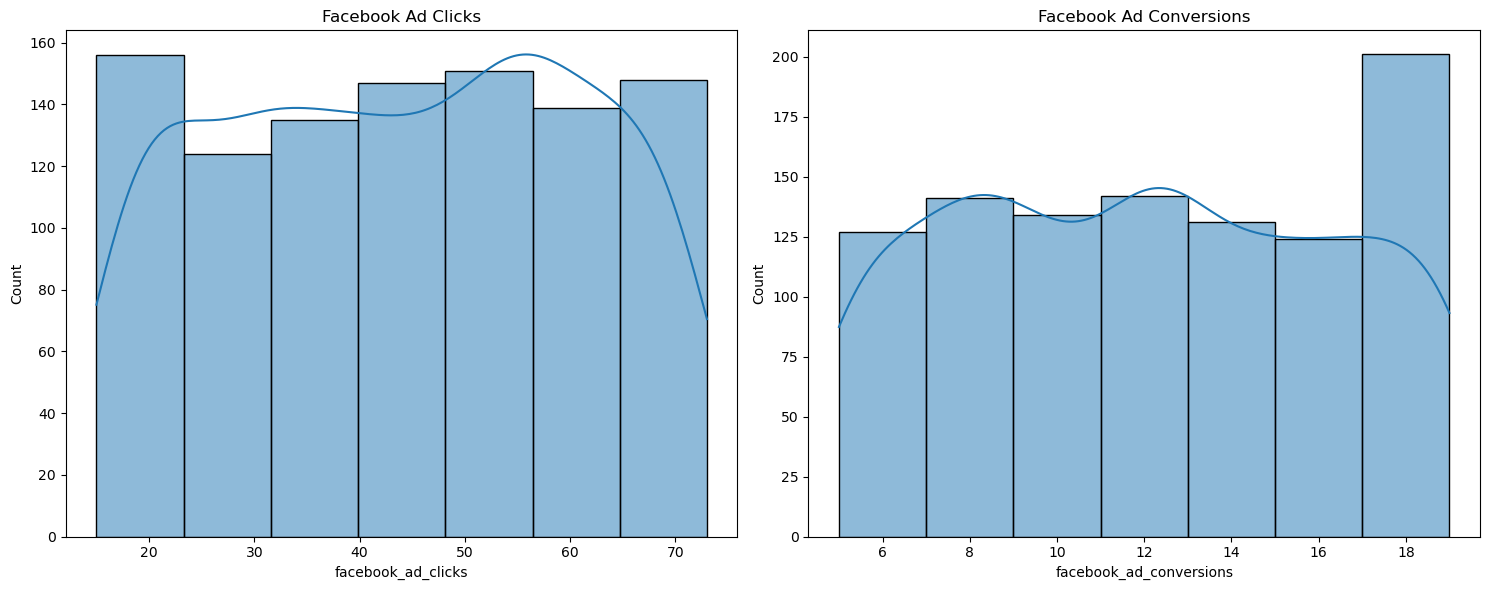

In [9]:
# Distribution of Facebook clicks and conversions
plt.figure(figsize=(15,6))
# Facebook Clicks
plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['facebook_ad_clicks'], bins=7, edgecolor='k', kde=True)

# Facebook Conversions
plt.subplot(1,2,2)
plt.title('Facebook Ad Conversions')
sns.histplot(df['facebook_ad_conversions'], bins=7, edgecolor='k', kde=True)

plt.tight_layout()
plt.show()

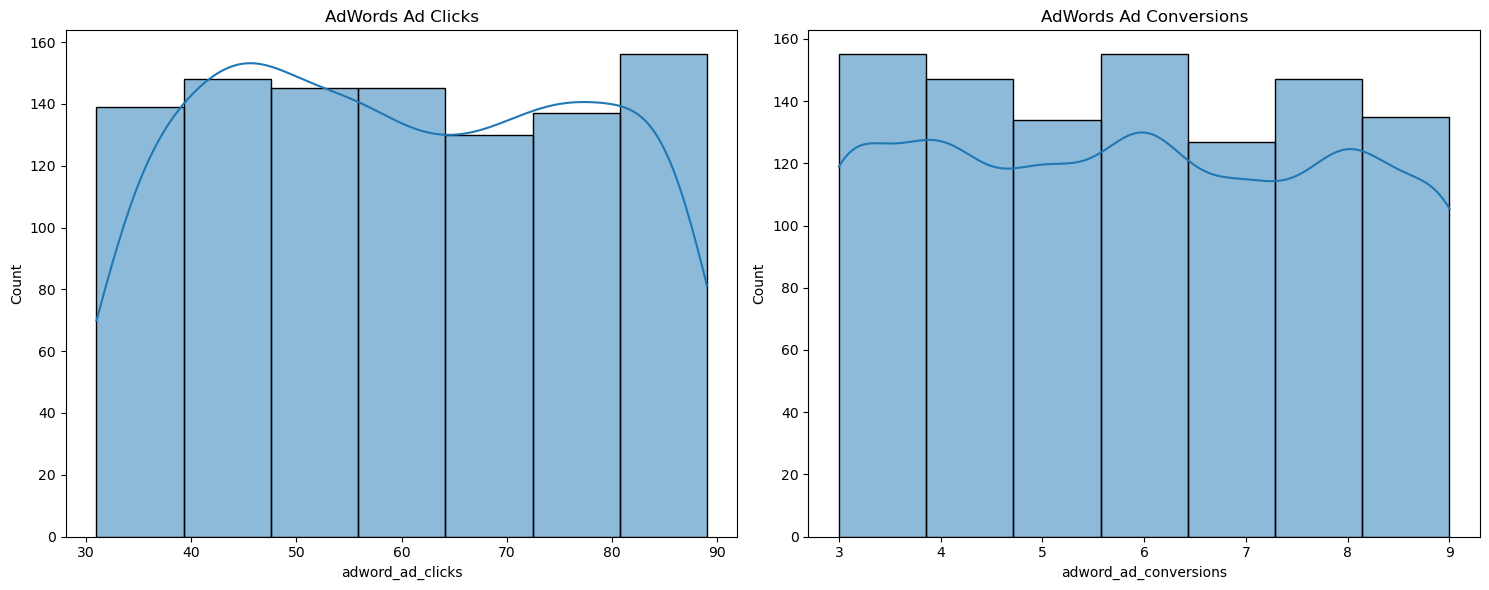

In [10]:
# Distribution of Adword clicks and conversions
plt.figure(figsize=(15,6))

# AdWords Clicks
plt.subplot(1,2,1)
plt.title('AdWords Ad Clicks')
sns.histplot(df['adword_ad_clicks'], bins=7, edgecolor='k', kde=True)

# AdWords Conversions
plt.subplot(1,2,2)
plt.title('AdWords Ad Conversions')
sns.histplot(df['adword_ad_conversions'], bins=7, edgecolor='k', kde=True)

plt.tight_layout()
plt.show()

The visual analysis of advertising performance reveals clear differences between Facebook Ads and Google AdWords. Facebook ad clicks are relatively evenly distributed within a moderate range, indicating stable and consistent user engagement across campaigns. Similarly, Facebook conversions show a wider spread, with values ranging higher than AdWords, suggesting that while performance varies, Facebook has the potential to achieve higher peak conversions. This indicates that Facebook is effective in driving both awareness and occasional high-performing outcomes.
In contrast, AdWords displays a broader range of clicks, reaching higher maximum values than Facebook, which suggests its ability to generate greater traffic. However, this engagement is more variable. When examining conversions, AdWords shows a narrower and more concentrated distribution, indicating more consistent but lower conversion outcomes compared to Facebook. This consistency suggests that AdWords campaigns are more controlled and likely target users with stronger intent.

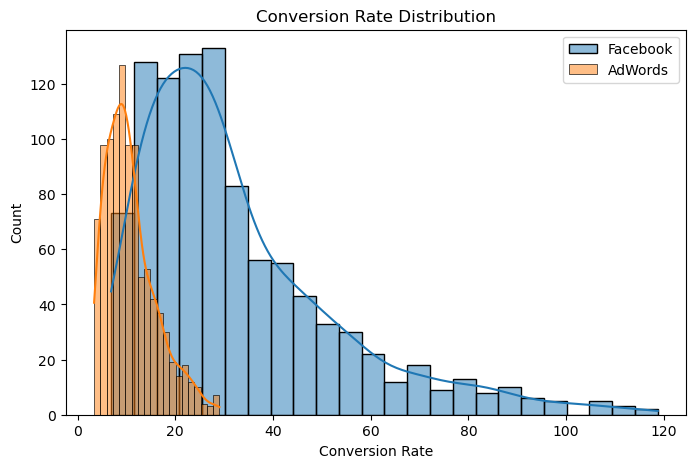

In [11]:
# Conversion rate distribution
plt.figure(figsize=(8,5))

sns.histplot(df['facebook_conversion_rate'], label='Facebook', kde=True)
sns.histplot(df['adword_conversion_rate'], label='AdWords', kde=True)

plt.title('Conversion Rate Distribution')
plt.xlabel('Conversion Rate')
plt.legend()

plt.show()

Facebook delivers higher and more varied conversion outcomes, while AdWords provides lower but more consistent conversion performance.

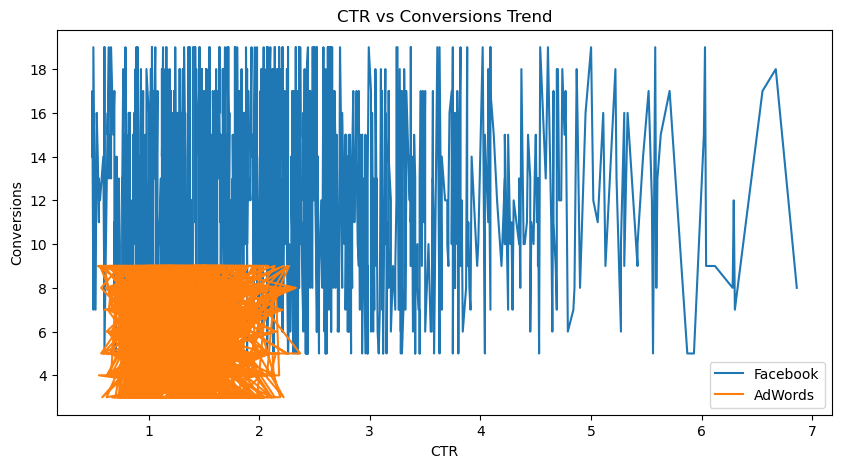

In [12]:
df_sorted = df.sort_values('facebook_ctr')

plt.figure(figsize=(10,5))

plt.plot(df_sorted['facebook_ctr'], df_sorted['facebook_ad_conversions'], label='Facebook')
plt.plot(df_sorted['adword_ctr'], df_sorted['adword_ad_conversions'], label='AdWords')

plt.xlabel('CTR')
plt.ylabel('Conversions')
plt.title('CTR vs Conversions Trend')
plt.legend()

plt.show()

* Facebook shows a wider spread of conversions across different CTR values

* Conversions for Facebook range roughly between 5 and 19, indicating stronger conversion performance

* AdWords conversions are concentrated in a smaller range, mostly between 3 and 9

* This indicates lower overall conversion outcomes compared to Facebook

* Facebook displays higher variability, meaning conversion performance changes significantly with CTR

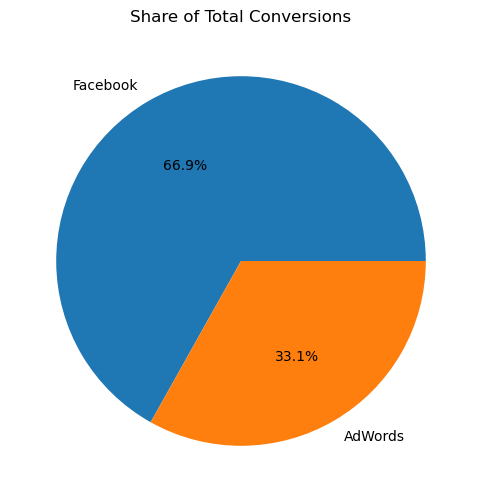

In [13]:
# Overall Conversion Distribution
total_conversions = [
    df['facebook_ad_conversions'].sum(),
    df['adword_ad_conversions'].sum()
]

labels = ['Facebook', 'AdWords']

plt.figure(figsize=(6,6))
plt.pie(total_conversions, labels=labels, autopct='%1.1f%%')

plt.title('Share of Total Conversions')

plt.show()

## Hypothesis Testing

**Hypothesis:**

Advertising on Facebook will result in a greater number of conversions compared to advertising on AdWords.

**Null Hypothesis (H₀):**

     There is no difference in the number of conversions between Facebook and AdWords, or AdWords performs better.

     H₀: μ_Facebook ≤ μ_AdWords

**Alternate Hypothesis (H₁):**

      The number of conversions from Facebook is greater than AdWords.

       H₁: μ_Facebook > μ_AdWords

In [14]:
print('Mean Conversion \n----------------------')

print('Facebook :', round(df['facebook_ad_conversions'].mean(),2))
print('AdWords  :', round(df['adword_ad_conversions'].mean(),2))


# Perform T-test
t_stats, p_value = stats.ttest_ind(
    a = df['facebook_ad_conversions'],
    b = df['adword_ad_conversions'],
    equal_var = False
)

print('\nT statistic:', t_stats, '\np-value:', p_value)


# Compare p-value with significance level
alpha = 0.05

if p_value < alpha:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")

Mean Conversion 
----------------------
Facebook : 11.98
AdWords  : 5.93

T statistic: 40.25906231407935 
p-value: 6.886351887267426e-237

p-value is less than significance value, Reject the null hypothesis


* The mean conversions for Facebook Ads is 11.98

* The mean conversions for AdWords is 5.93

* Facebook generates significantly higher conversions compared to AdWords

* The T-statistic value is 40.26, indicating a strong difference between the two groups

* The p-value is extremely small (6.88 × 10⁻²³⁷), which is far below the significance level of 0.05

* Since p-value < 0.05, the null hypothesis is rejected

* There is a statistically significant difference between Facebook and AdWords conversions

* Facebook Ads outperform AdWords in terms of conversion performance

* The difference observed is not due to random chance

* Facebook should be prioritized for conversion-focused campaigns, while AdWords can be used for supporting roles such as traffic generation